In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#custom imports
from clearshape.vecsets.ml.modules.trsfm_classificator import VecsetClassifierModule
from clearshape.vecsets.ml.modules.vecset_datamodul import VecsetDataModule


In [2]:
#set random seed for reproducibility
random.seed(42)
# Set the random seed for PyTorch
torch.manual_seed(42)

checkpoint_path = Path("/home/michelkruse/repos/clear-shape/src/clearshape/vecsets/ml/outputs/clearshape_classification/2025-05-14-16:43:59_None/lightning_logs/version_0/checkpoints/epoch=04-val_loss=0.5449.ckpt")

model = VecsetClassifierModule.load_from_checkpoint(checkpoint_path=checkpoint_path.as_posix())
model = model.to("cpu")
model.eval();

In [22]:
dataset = VecsetDataModule()
dataset.setup(stage="test")
test_dataloader = dataset.test_dataloader()

vecsets, targets = next(iter(test_dataloader))

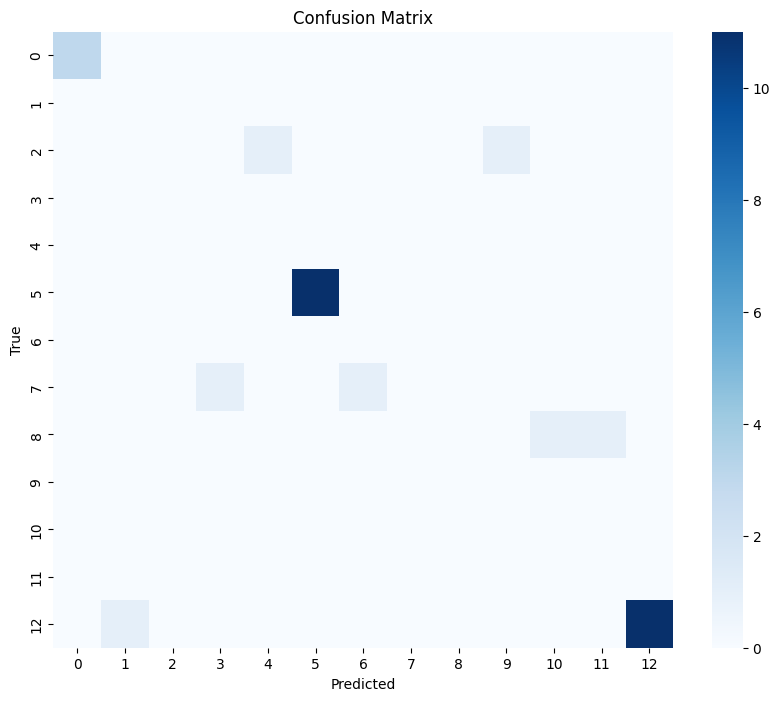

In [ ]:
#create a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Get the predictions from the model
predictions = model.predict_step((vecsets, targets)).numpy()
targets_cls = targets.argmax(dim=1).numpy()
# Get the true labels
# Compute the confusion matrix
cm = confusion_matrix(targets, predictions)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, fmt='d',annot=True cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
cm

array([[ 3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 11,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 11]])